## 1. Get the code and data

In [17]:
!rm -rf court-timeliness-monitor
!git clone https://github.com/nguyendoangiakhanh/court-timeliness-monitor.git

%cd court-timeliness-monitor

!pip install -q -r requirements.txt
!python run_pipeline.py

Cloning into 'court-timeliness-monitor'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 55 (delta 7), reused 51 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 588.07 KiB | 8.65 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/court-timeliness-monitor/court-timeliness-monitor/court-timeliness-monitor

Court Timeliness Monitor — synthetic data, for practice only

STAGE 1 — PROFILE
  rows                                 4,238
  unique case ids                      4,200
  duplicate case id rows                  38
  case_type variants                      21
  status variants                          7
  open cases (blank disposed_date)       908
  orphan / missing court_id               31
  disposed before filed                   18
  filed in the future                      5
  reported_days not numeric                0
  reported vs calculated mismatch   

Chart 1 - Monthly flow

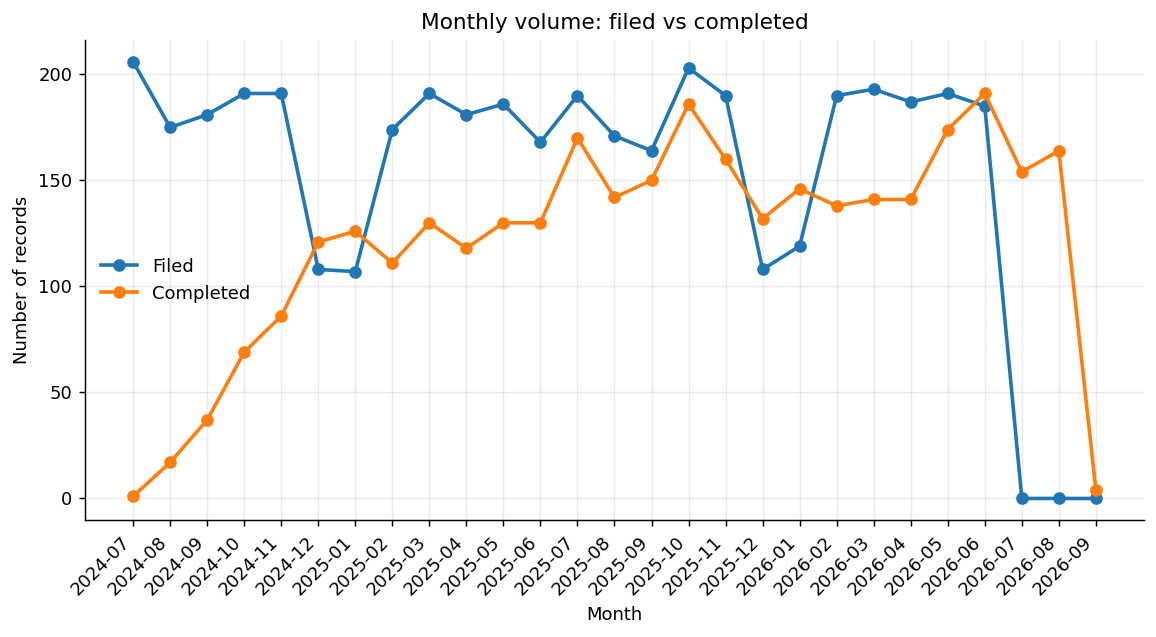

Saved to: outputs/colab_screenshot_charts/01_monthly_volume_simple.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("data/processed")
screenshot_dir = Path("outputs/colab_screenshot_charts")
screenshot_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def save_and_show(fig, filename):
    path = screenshot_dir / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved to: {path}")

# 1. Monthly intake vs completion
monthly = pd.read_csv(processed_dir / "monthly_flow.csv")
monthly = monthly.dropna(subset=["month"]).sort_values("month")

fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["filings"], marker="o", linewidth=2, label="Filed")
ax.plot(monthly["month"], monthly["disposals"], marker="o", linewidth=2, label="Completed")
ax.set_title("Monthly volume: filed vs completed")
ax.set_xlabel("Month")
ax.set_ylabel("Number of records")
ax.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
save_and_show(fig, "01_monthly_volume_simple.png")

Chart 2 - Completion-time distribution

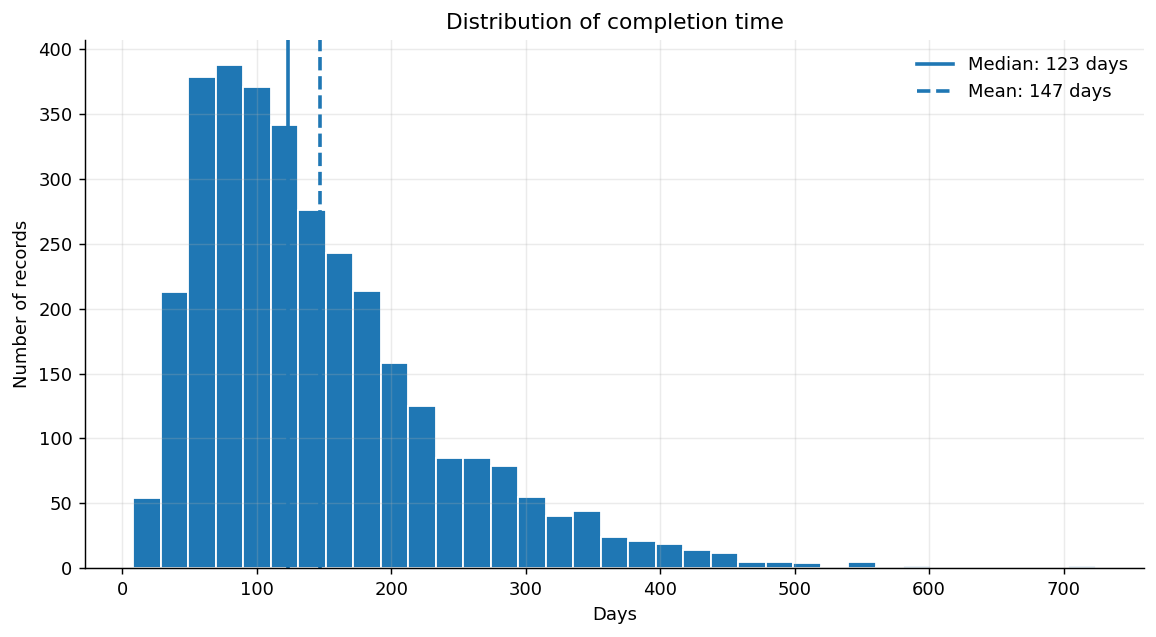

Saved to: outputs/colab_screenshot_charts/02_distribution_simple.png


In [19]:
from matplotlib.typing import ColorType
cases = pd.read_csv(processed_dir / "cases_clean.csv")

valid = cases[
    (cases["quality_flag"] == False) &
    (cases["waiting_days"].notna())
].copy()

median_days = valid["waiting_days"].median()
mean_days = valid["waiting_days"].mean()

fig, ax = plt.subplots()
ax.hist(valid["waiting_days"], bins=35, edgecolor="white")
ax.axvline(median_days, linestyle="-", linewidth=2, label=f"Median: {median_days:.0f} days")
ax.axvline(mean_days, linestyle="--", linewidth=2, label=f"Mean: {mean_days:.0f} days")
ax.set_title("Distribution of completion time")
ax.set_xlabel("Days")
ax.set_ylabel("Number of records")
ax.legend(frameon=False)
save_and_show(fig, "02_distribution_simple.png")

Chart 3 - Region comparison

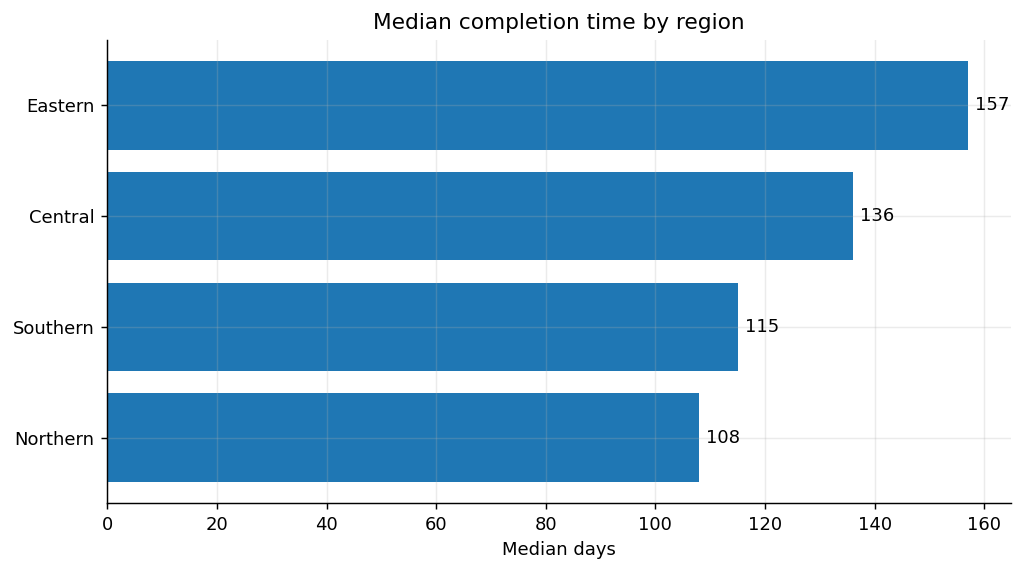

Saved to: outputs/colab_screenshot_charts/03_region_simple.png


In [20]:
region = pd.read_csv(processed_dir / "summary_by_region.csv")
region = region.dropna(subset=["median_days"]).sort_values("median_days")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(region["region"], region["median_days"])
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_title("Median completion time by region")
ax.set_xlabel("Median days")
ax.set_ylabel("")
save_and_show(fig, "03_region_simple.png")

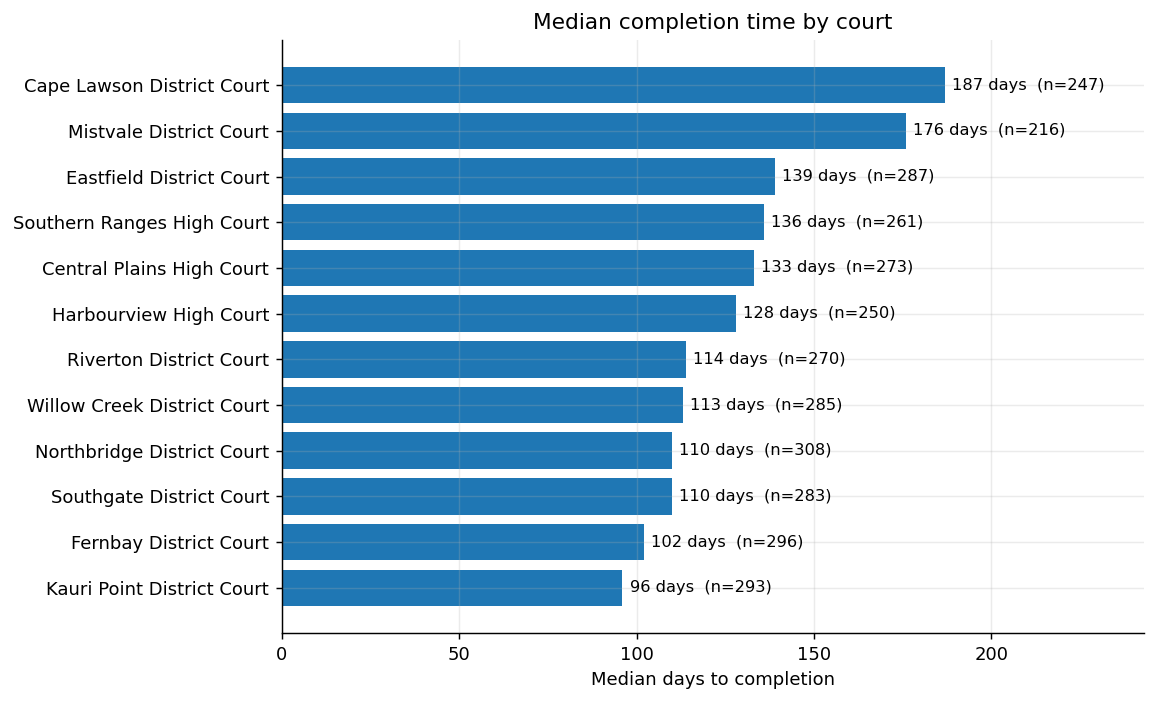

Saved to: outputs/colab_screenshot_charts/07_court_completion_time.png


In [25]:
# Median completion time by court

court = pd.read_csv(processed_dir / "summary_by_court.csv").copy()

court = (
    court
    .dropna(subset=["median_days"])
    .sort_values("median_days", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(court["court_name"], court["median_days"])

# Add median days and sample size beside each bar
labels = [
    f"{median:.0f} days  (n={int(n)})"
    for median, n in zip(court["median_days"], court["closed_cases"])
]

ax.bar_label(bars, labels=labels, padding=4, fontsize=9)

ax.set_title("Median completion time by court")
ax.set_xlabel("Median days to completion")
ax.set_ylabel("")

# Add a little space on the right for labels
ax.set_xlim(0, court["median_days"].max() * 1.30)

save_and_show(fig, "07_court_completion_time.png")

Chart 4 - Open records by age band

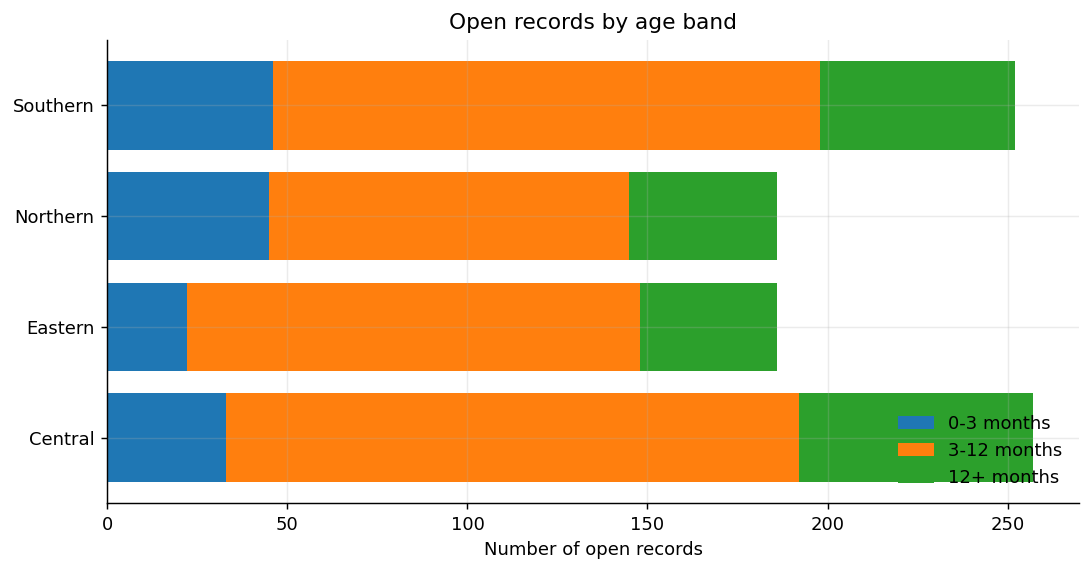

Saved to: outputs/colab_screenshot_charts/04_open_age_band_simple.png


In [21]:
backlog = pd.read_csv(processed_dir / "backlog_age_profile.csv")

pivot = (
    backlog
    .pivot(index="region", columns="age_band", values="open_cases")
    .fillna(0)
)

order = ["0-3 months", "3-12 months", "12+ months"]
pivot = pivot[[col for col in order if col in pivot.columns]]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
left = None

for col in pivot.columns:
    if left is None:
        ax.barh(pivot.index, pivot[col], label=col)
        left = pivot[col].copy()
    else:
        ax.barh(pivot.index, pivot[col], left=left, label=col)
        left += pivot[col]

ax.set_title("Open records by age band")
ax.set_xlabel("Number of open records")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
save_and_show(fig, "04_open_age_band_simple.png")

Chart 5 - Data-quality issues

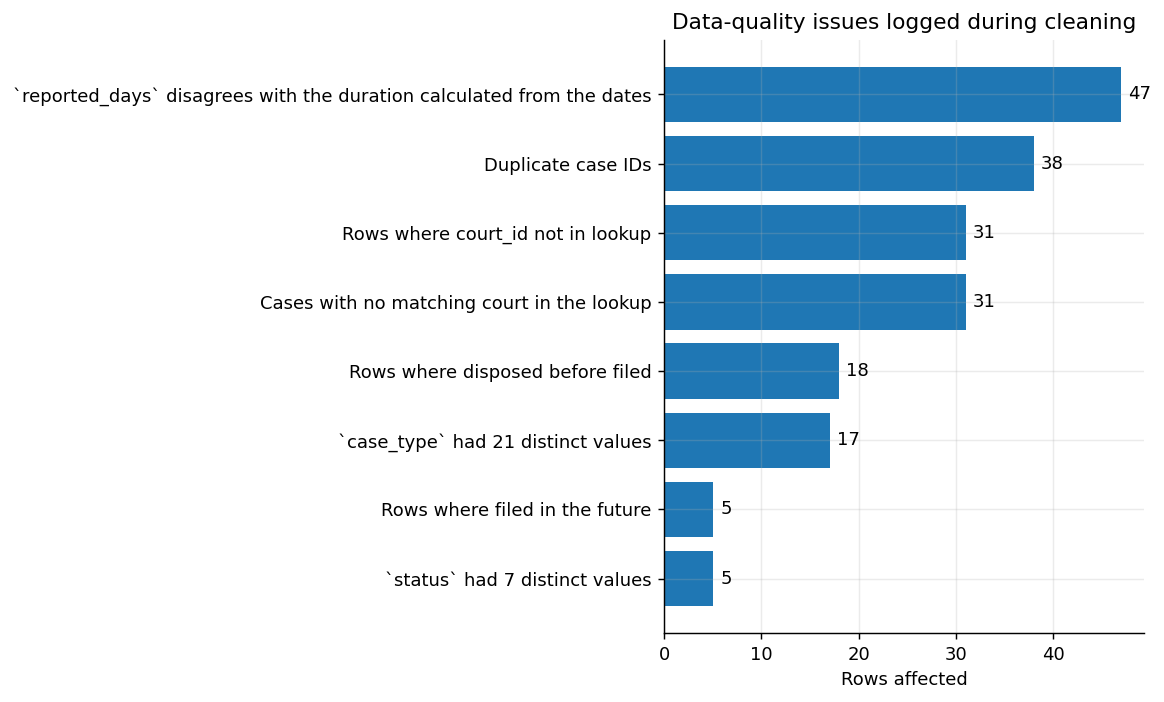

Saved to: outputs/colab_screenshot_charts/05_data_quality_simple.png


In [22]:
cleaning = pd.read_csv(processed_dir / "cleaning_log.csv")
cleaning_simple = cleaning.sort_values("rows_affected", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(cleaning_simple["issue"], cleaning_simple["rows_affected"])
ax.bar_label(bars, padding=4)
ax.set_title("Data-quality issues logged during cleaning")
ax.set_xlabel("Rows affected")
ax.set_ylabel("")
save_and_show(fig, "05_data_quality_simple.png")

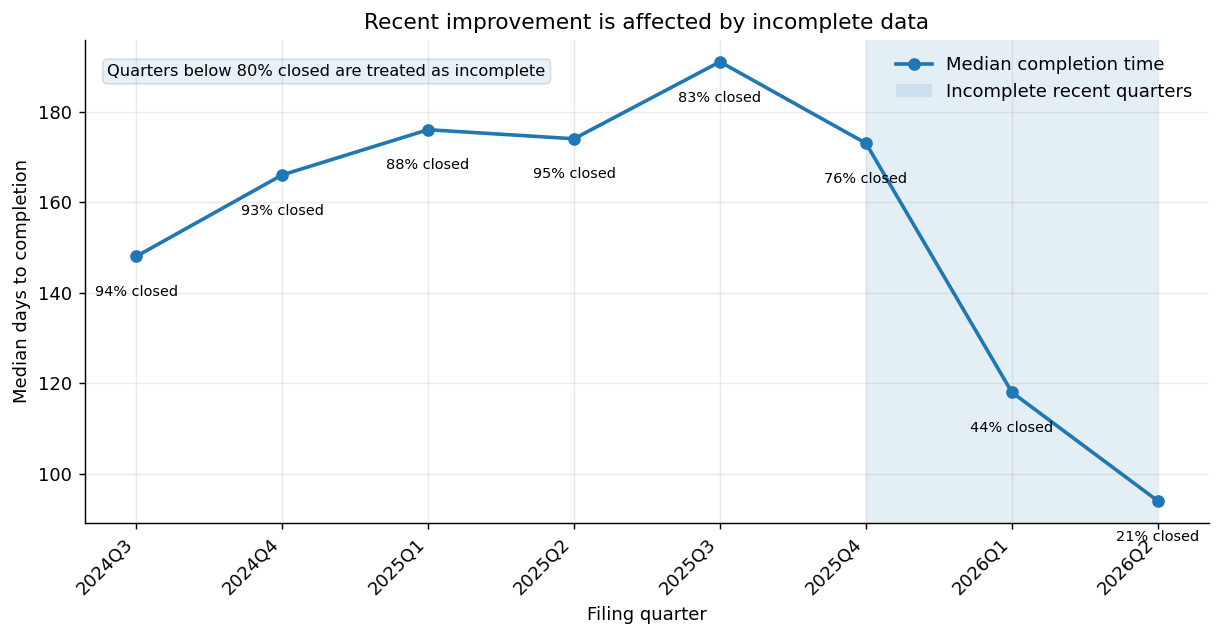

Saved to: outputs/colab_screenshot_charts/06_censoring_simple.png


In [33]:
# Censoring / closure-rate chart

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("data/processed")
screenshot_dir = Path("outputs/colab_screenshot_charts")
screenshot_dir.mkdir(parents=True, exist_ok=True)

q = pd.read_csv(processed_dir / "disposal_time_by_quarter.csv").copy()

# Use Eastern if it exists, because this is the region discussed in the README.
# Otherwise, use the region with the highest average median days.
if "Eastern" in q["region"].unique():
    focus_region = "Eastern"
else:
    focus_region = (
        q.dropna(subset=["median_days"])
         .groupby("region")["median_days"]
         .mean()
         .idxmax()
    )

focus = (
    q[q["region"] == focus_region]
    .dropna(subset=["median_days"])
    .sort_values("filed_quarter")
    .copy()
)

# Make sure closure_rate is numeric
focus["closure_rate"] = pd.to_numeric(focus["closure_rate"], errors="coerce")

fig, ax = plt.subplots(figsize=(9.5, 5))

# Main line: median completion time
ax.plot(
    focus["filed_quarter"],
    focus["median_days"],
    marker="o",
    linewidth=2,
    label="Median completion time"
)

# Highlight incomplete quarters
incomplete = focus[focus["complete"] == False]

if len(incomplete) > 0:
    first_incomplete = incomplete["filed_quarter"].iloc[0]
    last_quarter = focus["filed_quarter"].iloc[-1]

    ax.axvspan(
        first_incomplete,
        last_quarter,
        alpha=0.12,
        label="Incomplete recent quarters"
    )

# Add closure-rate labels under each point
for _, row in focus.iterrows():
    closure_label = f"{row['closure_rate']:.0%} closed"
    ax.annotate(
        closure_label,
        xy=(row["filed_quarter"], row["median_days"]),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

# Add 80% rule note
ax.text(
    0.02,
    0.95,
    "Quarters below 80% closed are treated as incomplete",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.10)
)

ax.set_title("Recent improvement is affected by incomplete data")
ax.set_xlabel("Filing quarter")
ax.set_ylabel("Median days to completion")

plt.xticks(rotation=45, ha="right")
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()

path = screenshot_dir / "06_censoring_simple.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved to: {path}")

01_monthly_volume_simple.png


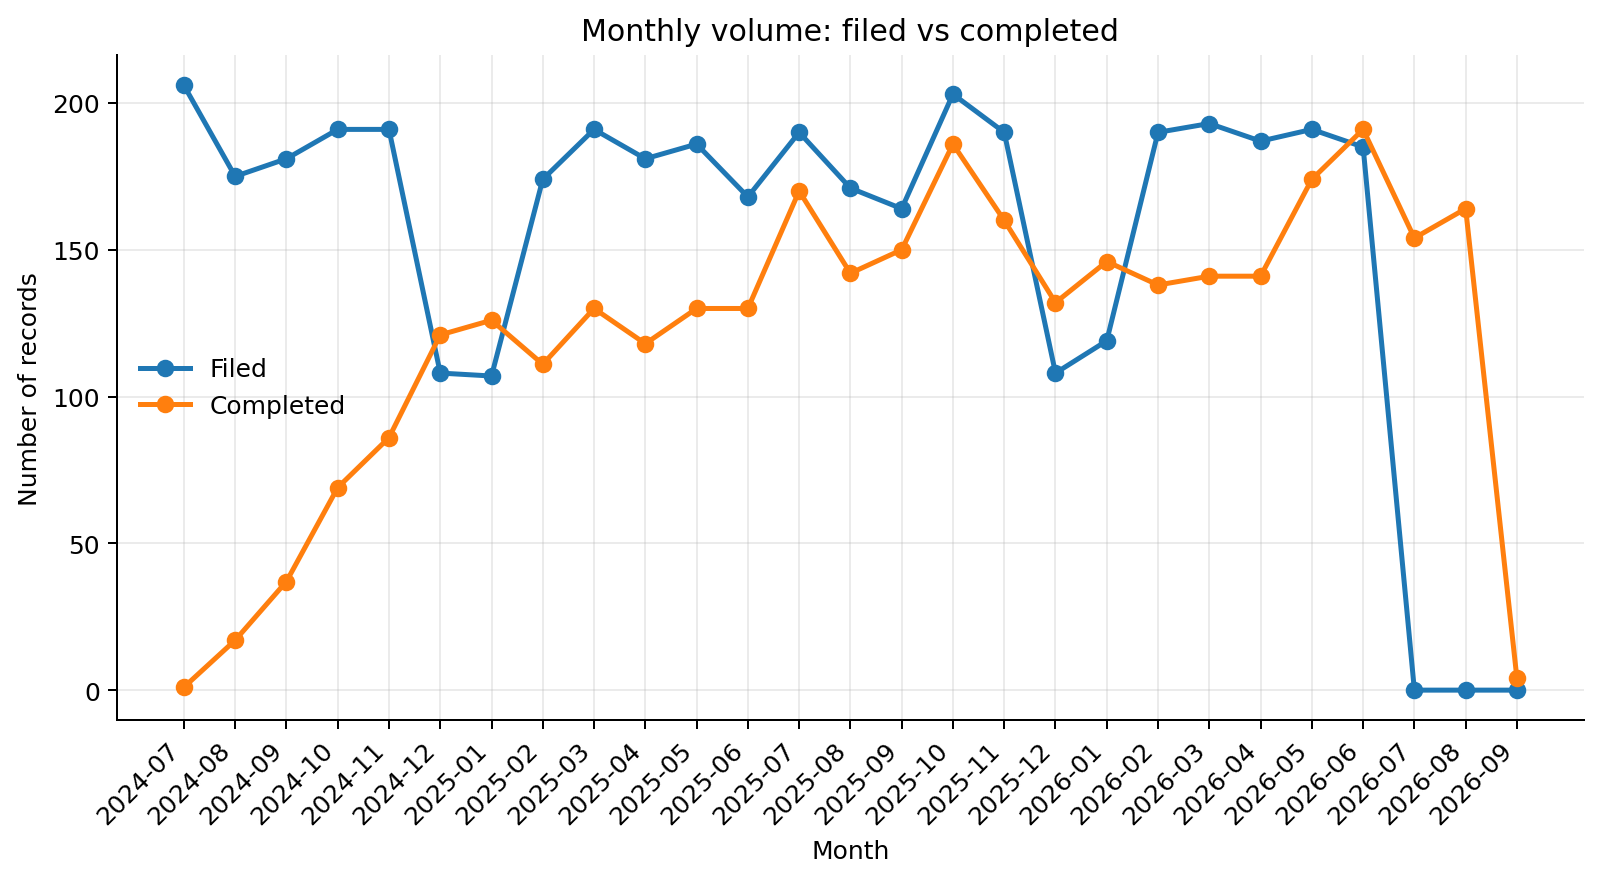

02_distribution_simple.png


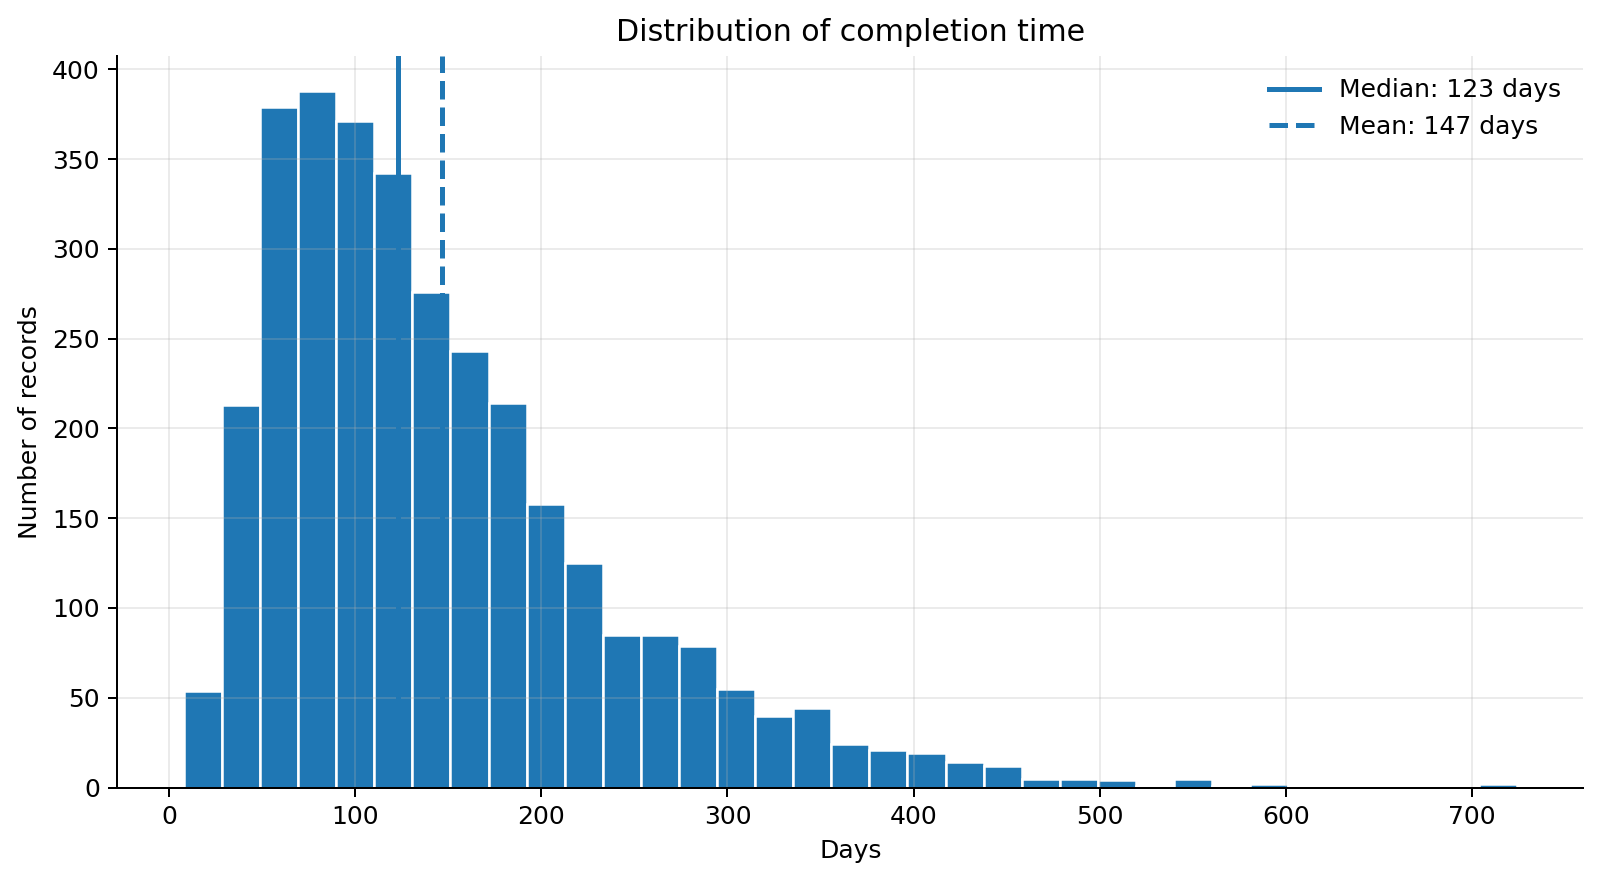

03_region_simple.png


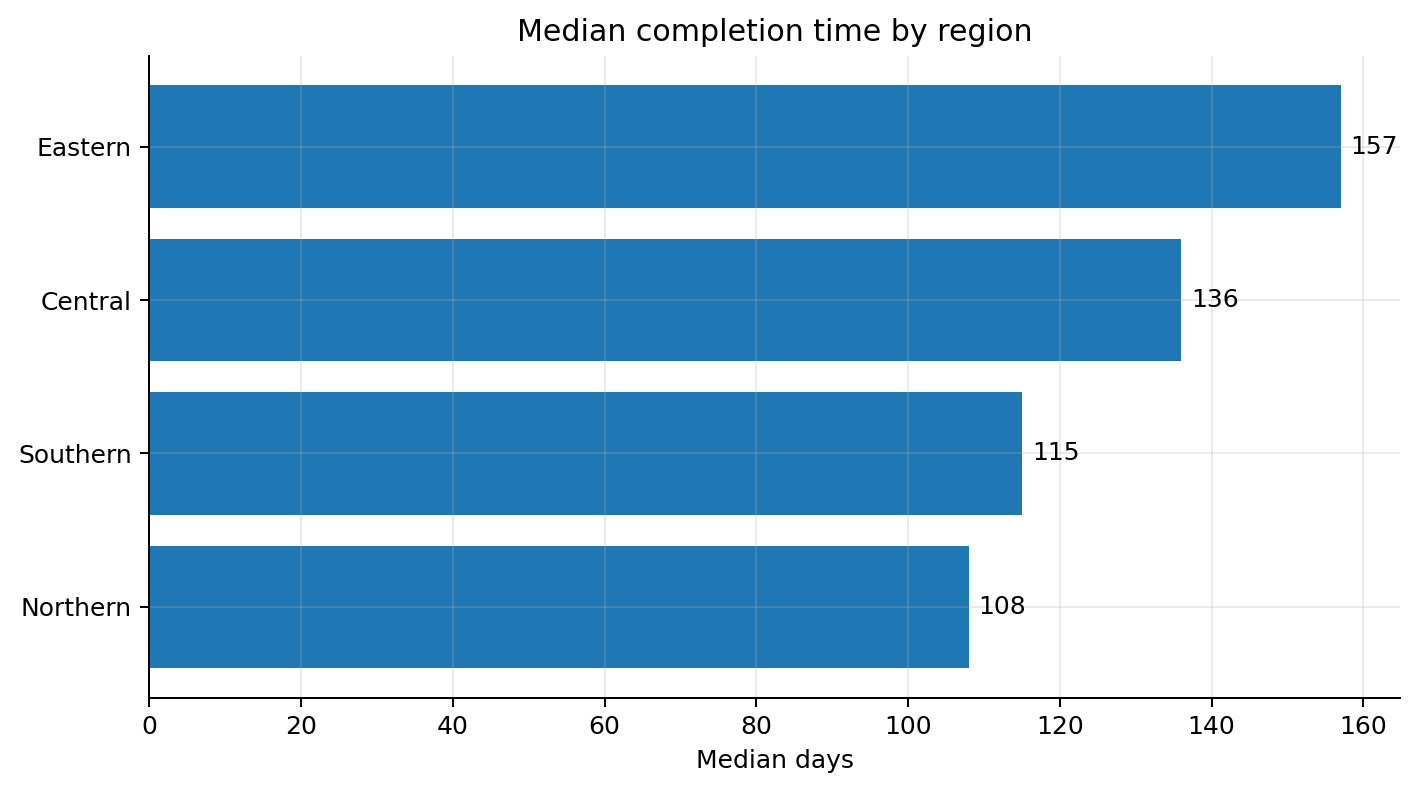

04_open_age_band_simple.png


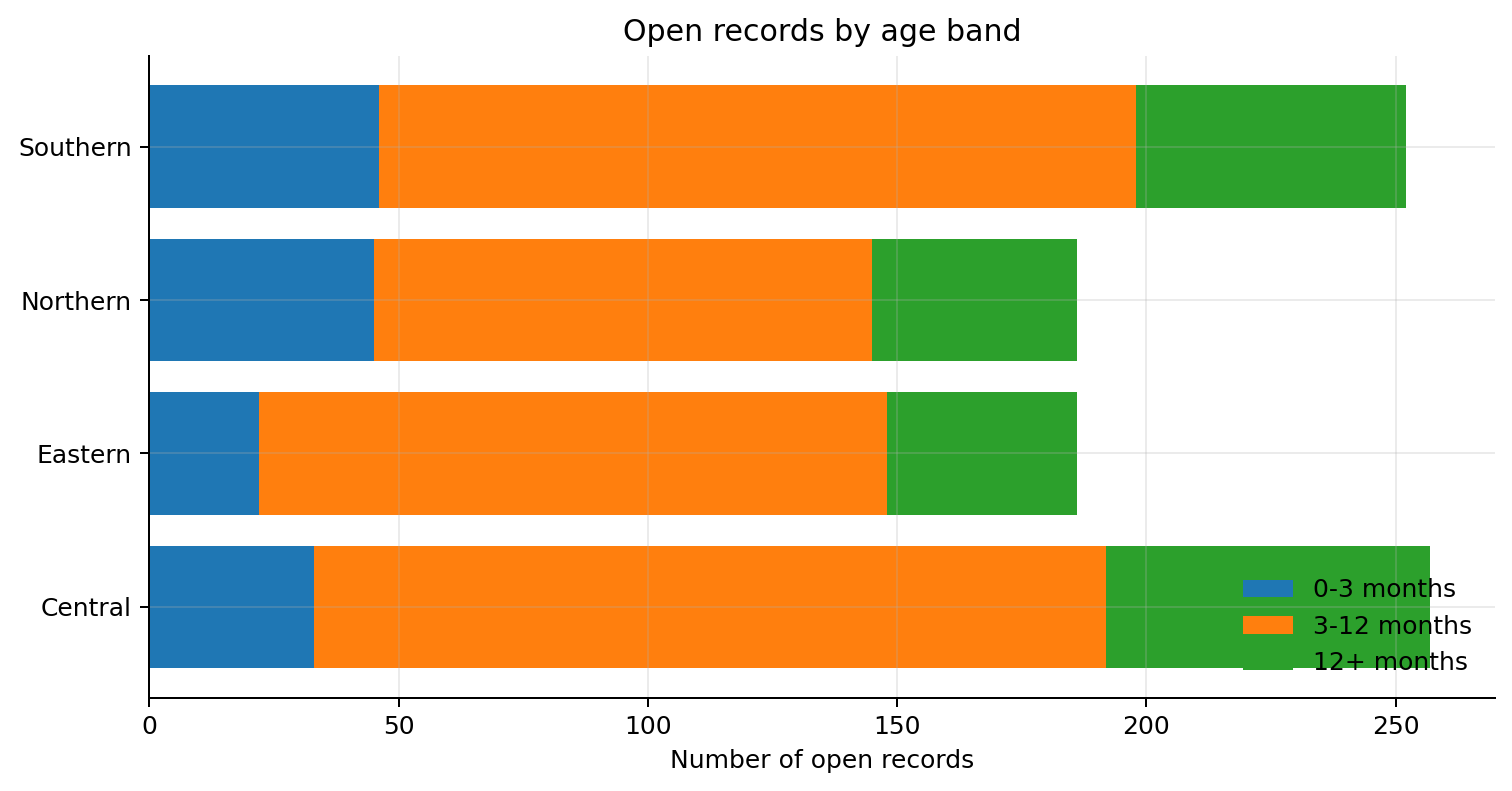

05_data_quality_simple.png


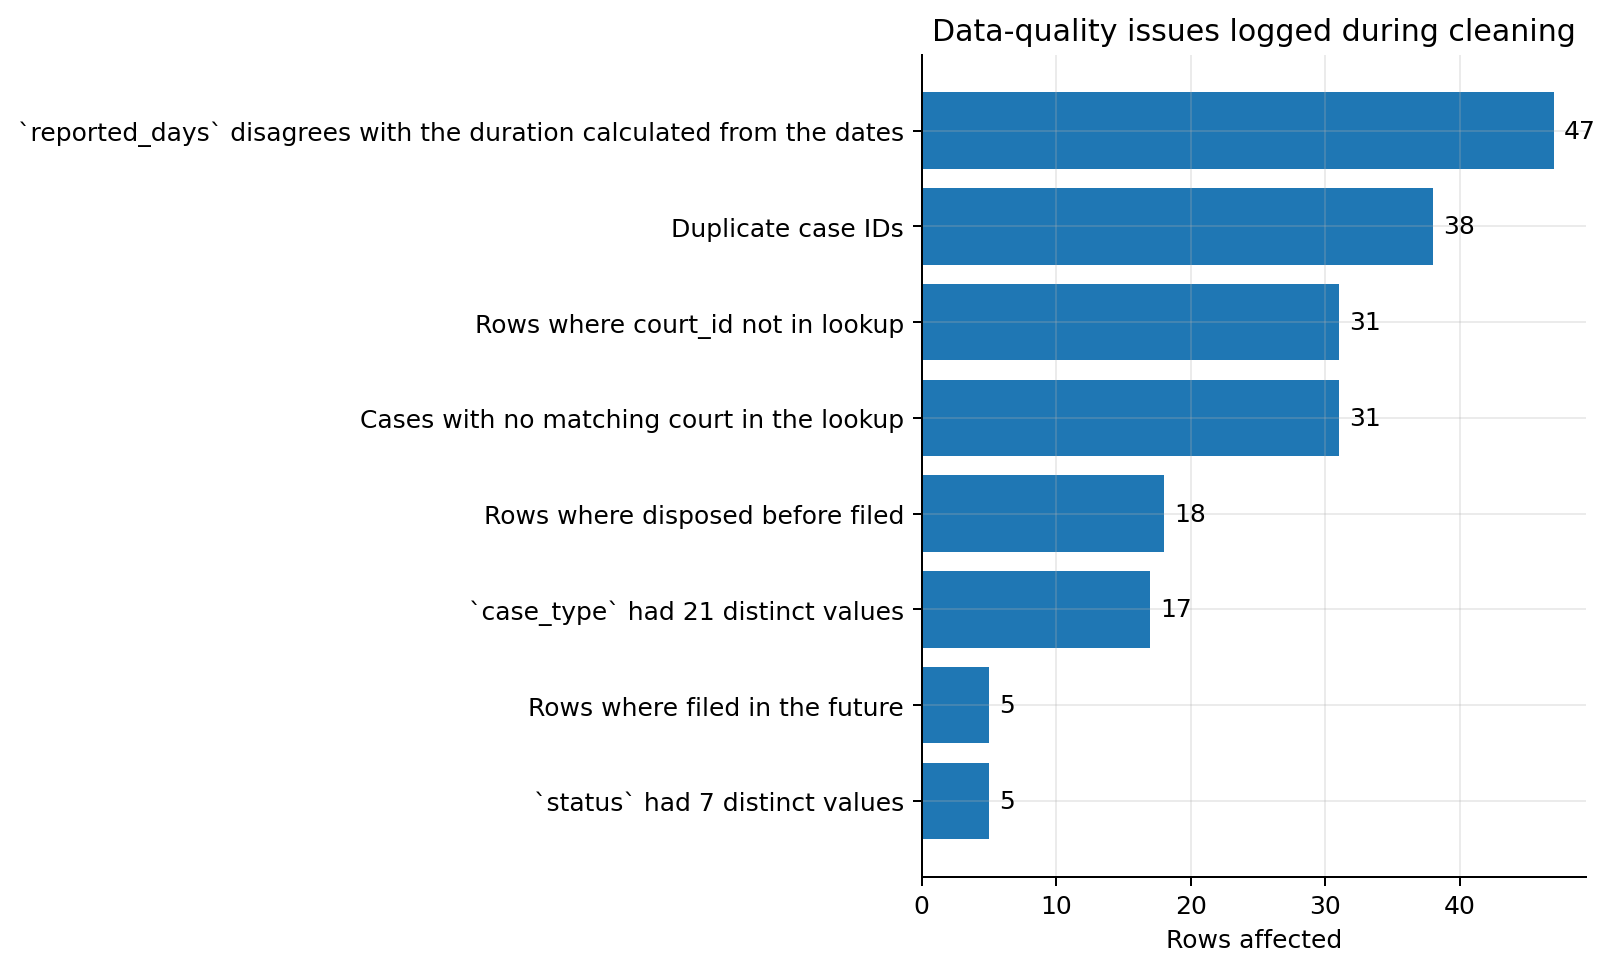

In [23]:
from IPython.display import Image, display

for path in sorted(screenshot_dir.glob("*.png")):
    print(path.name)
    display(Image(filename=str(path), width=850))

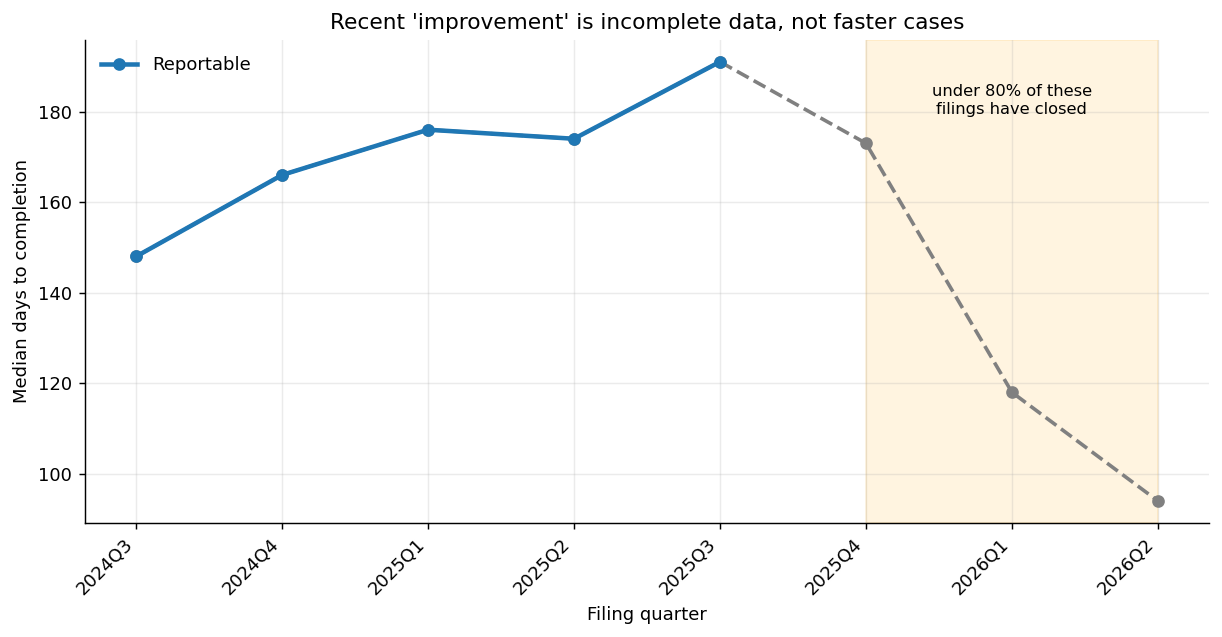

Saved to: outputs/colab_screenshot_charts/06_censoring_simple.png
filed_quarter  filed  closed  closure_rate  complete
       2024Q3     94      88         0.936      True
       2024Q4     88      82         0.932      True
       2025Q1     86      76         0.884      True
       2025Q2     94      89         0.947      True
       2025Q3     87      72         0.828      True
       2025Q4     91      69         0.758     False
       2026Q1     89      39         0.438     False
       2026Q2     91      19         0.209     False


In [24]:
quarter = pd.read_csv(processed_dir / "disposal_time_by_quarter.csv")
e = quarter[quarter["region"] == "Eastern"].sort_values("filed_quarter")

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(e["filed_quarter"], e["median_days"], marker="o", lw=2, color="grey", ls="--")
ok = e[e["complete"]]
ax.plot(ok["filed_quarter"], ok["median_days"], marker="o", lw=2.5, label="Reportable")

bad = e[~e["complete"]]
ax.axvspan(bad["filed_quarter"].iloc[0], e["filed_quarter"].iloc[-1], alpha=0.12, color="orange")
ax.text(bad["filed_quarter"].iloc[len(bad)//2], ax.get_ylim()[1]*0.95,
        "under 80% of these\nfilings have closed",
        ha="center", va="top", fontsize=9)

ax.set_title("Recent 'improvement' is incomplete data, not faster cases")
ax.set_xlabel("Filing quarter"); ax.set_ylabel("Median days to completion")
ax.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
save_and_show(fig, "06_censoring_simple.png")

print(e[["filed_quarter","filed","closed","closure_rate","complete"]].to_string(index=False))